# Explainable Boosting Machine (EBM)

> Interpretable AI for liquefaction prediction

**Exercise:** [![Open in Colab](https://img.shields.io/badge/Open%20in-Colab-F9AB00?style=flat-square&logo=googlecolab)](https://colab.research.google.com/github/kks32-courses/ai-geotech/blob/main/docs/02-xai/02a-ebm-exercise.ipynb)

**Solution:** [![Open in Colab](https://img.shields.io/badge/Open%20in-Colab-F9AB00?style=flat-square&logo=googlecolab)](https://colab.research.google.com/github/kks32-courses/ai-geotech/blob/main/docs/02-xai/02a-ebm.ipynb)

## What is EBM?

**Explainable Boosting Machine (EBM)** is a glass-box model designed to provide **high accuracy** while maintaining **complete interpretability**.

### Key Features:

- **Interpretable by design**: Unlike black-box models (neural networks, XGBoost), EBM is inherently interpretable
- **High accuracy**: Competitive performance with state-of-the-art models
- **Generalized Additive Model (GAM)**: Uses simple additive structure
- **Shows feature shapes**: Visualizes how each feature affects predictions
- **Detects interactions**: Can model pairwise feature interactions

### EBM Formula:

$$g(E[y]) = \beta_0 + \sum_{i} f_i(x_i) + \sum_{ij} f_{ij}(x_i, x_j)$$

Where:
- $f_i(x_i)$: Shape function for feature $i$ (learned using boosted trees)
- $f_{ij}(x_i, x_j)$: Pairwise interaction between features $i$ and $j$
- Each function shows exactly how a feature influences the prediction

### Why EBM for Geotechnical Engineering?

- **Engineering insight**: See exactly how GWD, PGA, Slope affect lateral spreading
- **Trust**: Understand model decisions before deployment
- **Debugging**: Identify if model learned physically reasonable relationships
- **Regulatory compliance**: Fully explainable for engineering reports

## Install packages

In [ ]:
# Colab: install the packages this notebook uses
%pip install -q interpret scikit-learn pandas

## Load data and prepare features

We use the same liquefaction dataset from Durante & Rathje (2021).

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load data
CSV_URL = 'https://raw.githubusercontent.com/kks32-courses/ai-geotech/refs/heads/main/docs/01-dtree/RF_YN_Model3.csv'
LOCAL_CSV = '../01-dtree/RF_YN_Model3.csv'  # local copy, read when the download fails

try:
    df = pd.read_csv(CSV_URL)
except Exception:
    df = pd.read_csv(LOCAL_CSV)

# Remove the identifier and the elevation column, which carries a no-data sentinel
df = df.drop(['Test ID', 'Elevation'], axis=1)

print(f"Dataset: {df.shape[0]} samples, {df.shape[1]-1} features")
df.head()

Dataset: 7291 samples, 4 features


,GWD (m),L (km),Slope (%),PGA (g),Target
0,0.370809,0.319117,5.465739,0.546270,0
1,1.300896,0.211770,0.905948,0.532398,0
2,1.300896,0.195947,0.849104,0.532398,0
3,1.788212,0.115795,0.451034,0.542307,0
4,1.637517,0.137265,0.941866,0.545784,1


## Train-test split

In [3]:
# Separate features and target
X = df.drop('Target', axis=1)
y = df['Target']

# Split into train and test (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 5832
Testing samples: 1459


## Train EBM Model

The constructor below takes the random seed and the number of pairwise interaction terms:

```
ebm = ExplainableBoostingClassifier(
    random_state=42,
    interactions=6,  # all pairwise interactions among the four features
)
```

In [4]:
from interpret.glassbox import ExplainableBoostingClassifier

# Create and train EBM
ebm = ExplainableBoostingClassifier(
    random_state=42,
    interactions=6  # all pairwise interactions: four features give C(4,2) = 6 pairs
)

ebm.fit(X_train, y_train)

print("\nModel Performance:")
print(f"Training accuracy: {ebm.score(X_train, y_train):.2%}")
print(f"Testing accuracy:  {ebm.score(X_test, y_test):.2%}")


Model Performance:
Training accuracy: 87.81%
Testing accuracy:  80.12%


## Global Explanation: Feature Importance

Let's see which features are most important for predicting lateral spreading.

In [5]:
from interpret import show

# Get global explanation
ebm_global = ebm.explain_global()
show(ebm_global)

<!-- http://127.0.0.1:7001/4526766736/ -->

### Understanding Feature Shapes

Click on each feature above to see its **shape function**. This shows exactly how that feature affects the prediction:

- **Y-axis (Score)**: Contribution to log-odds of lateral spreading
  - Positive score → increases spreading probability
  - Negative score → decreases spreading probability
  
- **X-axis**: Feature value

**Example interpretations:**
- **GWD (Ground Water Depth)**: 
  - Shallow water (low GWD) → High positive score → More spreading
  - Deep water (high GWD) → Negative score → Less spreading
  
- **L (Distance to free face)**:
  - Close to river (low L) → Positive score → More spreading
  - Far from river (high L) → Negative score → Less spreading

These shapes should match your **engineering intuition**!

## Individual Predictions: Local Explanations

Let's examine specific predictions to understand how the model arrives at its decisions.

### Example 1: Site with Lateral Spreading

In [6]:
# Find a spreading site
spreading_idx = y_test[y_test == 1].index[2]

# Get prediction and explanation
prediction = ebm.predict_proba(X_test.loc[[spreading_idx]])[0, 1]
ebm_local = ebm.explain_local(X_test.loc[[spreading_idx]], y_test.loc[[spreading_idx]])

print("Site features:")
print(X_test.loc[spreading_idx])
print(f"\nActual: Spreading (Target=1)")
print(f"Predicted probability of spreading: {prediction:.2%}")
print(f"\nExplanation (how each feature contributed):")

show(ebm_local)

Site features:
GWD (m)      2.001803
L (km)       1.548593
Slope (%)    2.296248
PGA (g)      0.450940
Name: 3805, dtype: float64

Actual: Spreading (Target=1)
Predicted probability of spreading: 98.72%

Explanation (how each feature contributed):


<!-- http://127.0.0.1:7001/4621586832/ -->

### Example 2: Site without Lateral Spreading

In [7]:
# Find a non-spreading site
no_spreading_idx = y_test[y_test == 0].index[10]

# Get prediction and explanation
prediction = ebm.predict_proba(X_test.loc[[no_spreading_idx]])[0, 1]
ebm_local = ebm.explain_local(X_test.loc[[no_spreading_idx]], y_test.loc[[no_spreading_idx]])

print("Site features:")
print(X_test.loc[no_spreading_idx])
print(f"\nActual: No spreading (Target=0)")
print(f"Predicted probability of spreading: {prediction:.2%}")
print(f"\nExplanation (how each feature contributed):")

show(ebm_local)

Site features:
GWD (m)      2.343796
L (km)       1.373441
Slope (%)    1.017609
PGA (g)      0.490698
Name: 544, dtype: float64

Actual: No spreading (Target=0)
Predicted probability of spreading: 20.29%

Explanation (how each feature contributed):


<!-- http://127.0.0.1:7001/4606705360/ -->

### Understanding Local Explanations

The bar chart shows:
- **Intercept**: the baseline log-odds of spreading, before any feature is considered
- **Each feature's contribution**: a score added to that baseline, also in log-odds
  - Blue bars (right) → Push prediction toward spreading
  - Red bars (left) → Push prediction away from spreading
- **Final prediction**: the intercept and the feature scores add to one log-odds value, and the
  logistic function $p = 1/(1 + e^{-z})$ turns that sum into the probability printed above

This allows engineers to:
1. Verify the prediction makes physical sense
2. Identify which site characteristics drove the decision
3. Compare model reasoning with engineering judgment

## Feature Interactions

EBM can detect when two features interact (their combined effect is not simply additive).

In [8]:
# List every term the model fitted, with its global importance
data = ebm_global.data()
terms = list(zip(data['names'], data['scores']))

print("Univariate shape functions:")
for name, score in terms:
    if ' & ' not in name:
        print(f"  {name:<24} {score:.4f}")

print("\nPairwise interactions (higher = stronger):")
for name, score in sorted((t for t in terms if ' & ' in t[0]), key=lambda t: -t[1]):
    print(f"  {name:<24} {score:.4f}")

Univariate shape functions:
  GWD (m)                  0.3243
  L (km)                   0.4736
  Slope (%)                0.1661
  PGA (g)                  0.7452

Pairwise interactions (higher = stronger):
  L (km) & PGA (g)         0.8499
  GWD (m) & PGA (g)        0.5347
  GWD (m) & L (km)         0.4794
  L (km) & Slope (%)       0.2296
  GWD (m) & Slope (%)      0.1903
  Slope (%) & PGA (g)      0.1862


**In the dashboard rendered earlier, click on an interaction term** (like "GWD & PGA") to see the 2D heatmap showing how the combination of two features affects spreading.

For example:
- **GWD × PGA**: Does shallow water + high shaking create a synergistic effect?
- **L × Slope**: Does being close to a river on a steep slope amplify risk?

## Model Performance Metrics

In [9]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# Predictions
y_pred = ebm.predict(X_test)
y_pred_proba = ebm.predict_proba(X_test)[:, 1]

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Spreading', 'Spreading']))

# ROC-AUC
auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nROC-AUC Score: {auc:.4f}")

Classification Report:
              precision    recall  f1-score   support

No Spreading       0.80      0.88      0.84       844
   Spreading       0.81      0.69      0.75       615

    accuracy                           0.80      1459
   macro avg       0.80      0.79      0.79      1459
weighted avg       0.80      0.80      0.80      1459


ROC-AUC Score: 0.8843


## Confusion Matrix

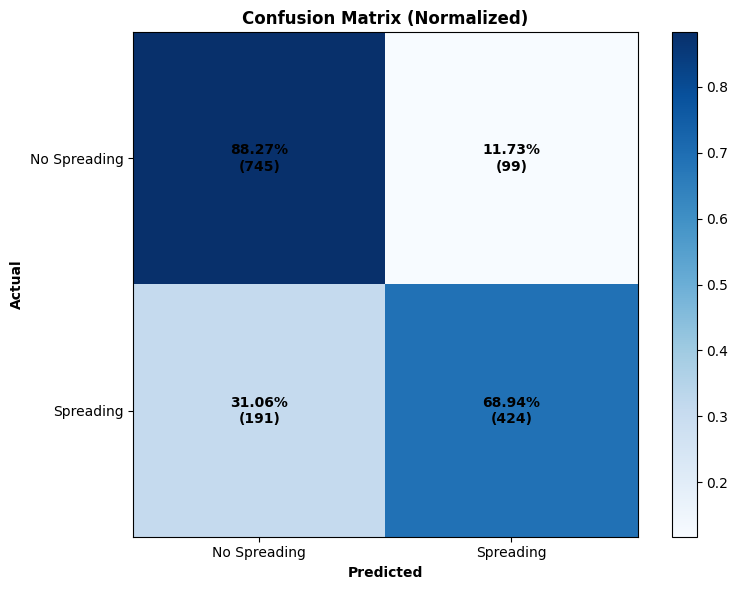

In [10]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_normalized, cmap='Blues')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['No Spreading', 'Spreading'])
ax.set_yticklabels(['No Spreading', 'Spreading'])
ax.set_xlabel('Predicted', fontweight='bold')
ax.set_ylabel('Actual', fontweight='bold')
ax.set_title('Confusion Matrix (Normalized)', fontweight='bold')

# Add text annotations
for i in range(2):
    for j in range(2):
        text = ax.text(j, i, f"{cm_normalized[i, j]:.2%}\n({cm[i, j]})",
                      ha="center", va="center", color="black", fontweight='bold')

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## Summary: EBM vs Other Models

| Model | Test accuracy | Interpretability | Engineering Insights |
|-------|---------------|------------------|---------------------|
| Decision Tree (depth 7) | 76.1% | High | Readable rules, but unstable |
| Random Forest | 80.8% | Low | Impurity importance and post-hoc SHAP |
| XGBoost | 85.3% | Very Low | Post-hoc SHAP |
| **EBM** | **80.1%** | **Highest** | **Built-in, exact feature shapes** |

The first three numbers come from `01b`, measured on its 729-site test set; the EBM number is
measured on the 1459-site test set of this notebook. The two notebooks split the data
differently, so the four rows are not measured on the same sites and the comparison is
indicative, not exact.

EBM matches the random forest and gives up about four points of accuracy to XGBoost. In return
you can read every term the model uses. That trade is the point of this chapter.

### Key Advantages of EBM:

1. **Inherently interpretable**: No need for post-hoc explanations (SHAP, LIME)
2. **Exact feature shapes**: See precisely how GWD, PGA, etc. affect predictions
3. **Interaction detection**: Automatically finds synergistic effects
4. **Accuracy**: matches the random forest here and trails XGBoost by about four points
5. **Engineering validation**: Easy to verify if model learned physics correctly

### When to use EBM:

- ✅ When model interpretability is critical (regulatory, safety-critical applications)
- ✅ When you need to understand feature relationships
- ✅ When you want to validate model against domain knowledge
- ✅ When stakeholders need to trust predictions

### Learn more:

- **InterpretML Documentation**: https://interpret.ml/docs/ebm.html
- **Paper**: Lou et al. (2013) "Accurate Intelligible Models with Pairwise Interactions"